#Taller 8 - Metodos Computacionales
Sofia Moscoso Ortiz - 1015068640

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import numpy as np
from scipy.integrate import odeint

# **1**
Tenemos que resolver la *EDO de segundo orden* (ecuaciones de movimiento de Newton con aceleración constante)

$$
\frac{d^2 y}{dt^2} = -g
$$

donde $ g $ es la aceleración constante debida a la gravedad y $ y (t) $ es la posición de la pelota en función del tiempo (su
trayectoria).

El esquema de Euler para cualquier *EDO de primer orden*

$$ \frac{dy}{dt} = f(y, t) $$

es

$$ y(t + h) = y(t) + h f(y(t), t). $$

Para resolver la ecuación de movimiento original de segundo orden, hacemos uso del hecho de que una EDO de $ n $ -ésimo orden puede escribirse como $ n $ EDO acopladas de primer orden, a saber

$$
\begin{align}
\frac{dy}{dt} &= v\\
\frac{dv}{dt} &= -g.
\end{align} $$

Resuelva cada una de las EDO de primer orden con el algoritmo de Euler:

$$
\begin{align}
y(t + h) &= y(t) + h v(t)\\
v(t + h) &= v(t) - h g.
\end{align} $$


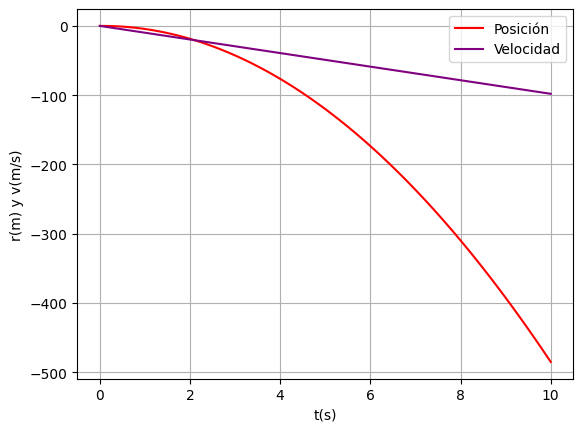

In [3]:
def euler(y0, v0, n):
    h , g = 0.1 , 9.8
    y_ = [y0]
    v_ = [v0]
    for _ in range(n):
        y1 = y_[-1] + h * v_[-1]
        v1 = v_[-1] - h * g
        y_.append(y1)
        v_.append(v1)
    return y_, v_

y_s, v_s = euler(0, 0, 100)
t0 , h = 0 , 0.1
t = [t0 + i * h for i in range(101)]
plt.plot(t, y_s, label='Posición' , color = "red")
plt.plot(t, v_s, label='Velocidad' , color = "purple")
plt.xlabel('t(s)')
plt.ylabel("r(m) y v(m/s)")
plt.legend()
plt.grid()
plt.show()

# **2**
Repita el ejercicio anterior sin desacoplar el sistema, es decir, usando velet.

In [4]:
def verlet(y0, v0, n):
    h,g = 0.1 , 9.8
    y_ = [y0]
    v_ = [v0]

    for _ in range(n):
        y1 = 2 * y_[-1] - y_[-2] + h**2 * v_[-1]
        v1 = v_[-1] + 0.5 * h * (f(v_[-1], g) + f(v_, g))
        y_.append(y1)
        v_.append(v1)
    return y_, v_

def f(v, g):
    # Función de fuerza (derivada de la velocidad)
    return -g

y_s , v_s = verlet(0, 10, 100)
t = [t0 + i * h for i in range(101)]

plt.plot(t, y_s, label='Posición' , color = "purple")
plt.plot(t, v_s, label='Velocidad', color = "red")
plt.xlabel('Tiempo')
plt.legend()
plt.ylabel("r(m) y v(m/s)")
plt.grid()
plt.show()


IndexError: ignored

# **3**
Deducir el sistema de ecuaciones lineales de primer orden para la ecuación,

$$\tan(t)\frac{d^{3}}{dt^{3}}y(t) + t\frac{d}{dt}y(t) +t^2y(t)=3\,\hbox{sen}(t).$$

Resolver usando rk2 y rk4.

In [5]:
def ecuacion(t, y):
    y1, y2, y3 = y
    dy1dt = y2
    dy2dt = y3
    dy3dt = (1/np.tan(t))*(3*np.sin(t) - t**2*y1 - t*y2)
    return [dy1dt, dy2dt, dy3dt]

In [6]:
def runge_kutta2(h, t, y):
    k1 = h * np.array(ecuacion(t, y))
    k2 = h * np.array(ecuacion(t + h, y + k1))
    y1 = y + 0.5 * (k1 + k2)
    return y1

def runge_kutta4(h, t, y):
    k1 = h * np.array(ecuacion(t, y))
    k2 = h * np.array(ecuacion(t + 0.5 * h, y + 0.5 * k1))
    k3 = h * np.array(ecuacion(t + 0.5 * h, y + 0.5 * k2))
    k4 = h * np.array(ecuacion(t + h, y + k3))
    y1 = y + (1/6) * (k1 + 2*k2 + 2*k3 + k4)
    return y1

<ipython-input-5-0db0cb4361f8>:5: RuntimeWarning: divide by zero encountered in double_scalars
  dy3dt = (1/np.tan(t))*(3*np.sin(t) - t**2*y1 - t*y2)
<ipython-input-5-0db0cb4361f8>:5: RuntimeWarning: invalid value encountered in double_scalars
  dy3dt = (1/np.tan(t))*(3*np.sin(t) - t**2*y1 - t*y2)


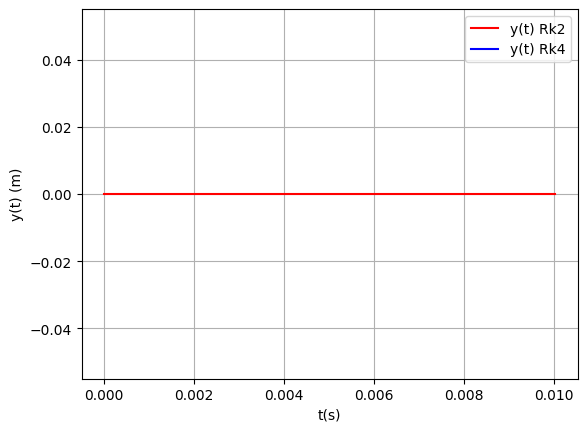

In [7]:
t0 , y0 = 0 , [0, 0, 0]  # [y1, y2, y3]
t_ = np.linspace(t0, 5, 500)

y_rk2 = [y0]
h = t_[1] - t_[0]
for t in t_[:-1]:
    y0 = runge_kutta2(h, t, y0)
    y_rk2.append(y0)

y0 = [0, 0, 0]
y_rk4 = [y0]
for t in t_[:-1]:
    y0 = runge_kutta4(h, t, y0)
    y_rk4.append(y0)

y1_rk2 = [y[0] for y in y_rk2]
y1_rk4 = [y[0] for y in y_rk4]

# Graficar resultados
plt.plot(t_, y1_rk2, label='y(t) Rk2' , color = "red")
plt.plot(t_, y1_rk4, label='y(t) Rk4' , color = "blue")
plt.xlabel('t(s)')
plt.ylabel('y(t) (m)')
plt.grid()
plt.legend()
plt.show()


# **4**
[La ecuación de Duffing](https://en.wikipedia.org/wiki/Duffing_equation): definida por

$$\ddot{x} + \delta \dot{x} + \alpha x + \beta x^3 = \gamma \cos (\omega t)$$

compruebe que tiene comportamiento caótico para $\alpha =1, \beta =5, \delta =0.02, \gamma =8$ y $\omega =0.5$

In [8]:
alpha , beta , delta  , gamma , omega =  1 , 5 , 0.02 , 8 , 0.5

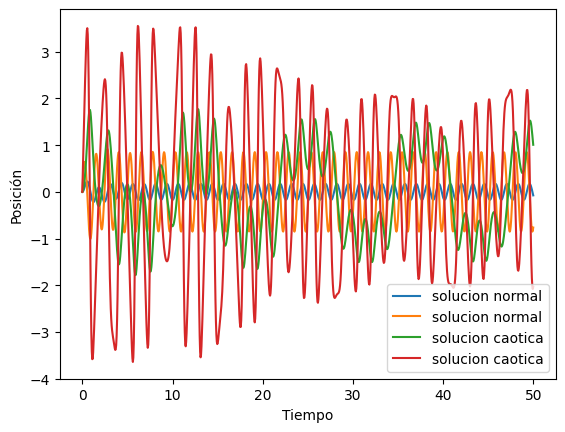

In [12]:
def a(y, t, delta, alpha, beta, gamma, omega):
    x, v = y
    dydt = [v, -delta * v - alpha * x - beta * x**3 + gamma * np.cos(omega * t)]
    return dydt

x0, v0   = 0.0 , 0.0
y0 = [x0, v0]

t = np.linspace(0, 50, 1000)
solucion = odeint(a, y0, t, args=(delta, alpha, beta, gamma, omega))
solucion2 = odeint(a, y0, t, args=(1, 2, 3, 4, 5))

plt.plot(t, solucion2 , label = "solucion normal")
plt.plot(t, solucion , label = "solucion caotica")
plt.xlabel('Tiempo')
plt.ylabel('Posición')
plt.legend()
plt.show()